In [149]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
X,y=make_circles(n_samples=50,factor=0.5,noise=0.03,random_state=4)

In [155]:
def cal_dist(pt1,pt2):
    return np.linalg.norm(pt1-pt2)


class DBSCAN:
    def __init__(self,eps,min_samples):
        self.eps=eps
        self.min_samples=min_samples

    def train(self,X):
        core_ind=[]
        Border_ind=[]
        Noise_ind=[]
        neighbourhood={}
        review=[]
        for i in range(len(X)):
            neighbourhood[i]=[]
            for j in range(len(X)):
                if j==i:
                    continue
                dist=cal_dist(X[i],X[j])
                if dist<=self.eps:
                    neighbourhood[i].append(j)
            if len(neighbourhood[i])>=self.min_samples:
                core_ind.append(i)
            else:
                review.append(i)

        for i in review:
            border=False
            for neighbours_ind in neighbourhood[i]:
                if len(neighbourhood[neighbours_ind])>=self.min_samples:
                    Border_ind.append(i)
                    border=True
                    break
            if not border:
                Noise_ind.append(i)

        self.labels=[-1 for i in range(len(X))]
        unclustered_core=core_ind[:]

        clusterNo=0
        # print(neighbourhood)
        for pt1 in unclustered_core:
            # print(pt1)
            if self.labels[pt1]!=-1:
                continue
            self.labels[pt1]=clusterNo
            nbrs=neighbourhood[pt1]
            q=[pt1]
            while q:
                current=q.pop(0)
                for i in neighbourhood[current]:
                    if self.labels[i]==-1:
                        if i in core_ind:
                            q.append(i)
                        self.labels[i]=clusterNo
            clusterNo+=1

        for pts in Border_ind:
            min_dist=float('inf')
            min_nbr=-1
            for i in neighbourhood[pts]:
                cdist=cal_dist(X[i],X[pts])
                if cdist<min_dist and self.labels[i]!=-1:
                    min_dist=cdist
                    min_nbr=i
            if min_nbr!=-1:
                self.labels[pts]=self.labels[min_nbr]

In [160]:
db=DBSCAN(0.4,1)

In [161]:
db.train(X)

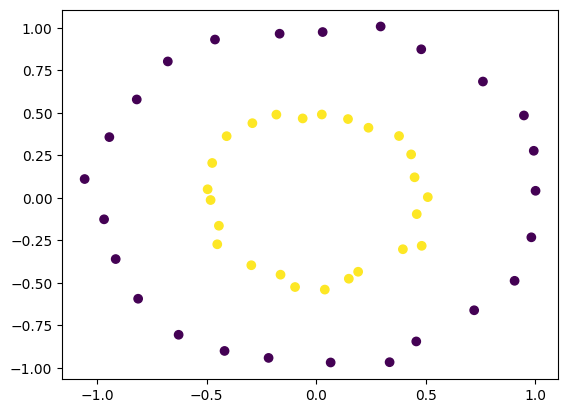

In [163]:
plt.scatter(X[:,0],X[:,1],c=db.labels)